# 8INF867 — Mini-Projet 2 : Apprentissage Automatique Avancé
## Partie 2.4 — Entraînement d'un Agent par Apprentissage par Renforcement (DQN)

| | |
|---|---|
| **Algorithme** | Deep Q-Network (DQN) |
| **Domaine d'application** | Contrôle par équilibrage — CartPole-v1 |
| **Framework** | TensorFlow / Keras + Gymnasium |
| **Référence** | Mnih et al., *Playing Atari with Deep Reinforcement Learning*, DeepMind 2015 |

---

## 2.4.1 — Synthèse de l'Apprentissage par Renforcement

### 1. Définition et Paradigme

L'**apprentissage par renforcement** (AR) est un paradigme d'apprentissage automatique où un **agent** apprend à prendre des décisions optimales en interagissant avec un **environnement**. Contrairement à l'apprentissage supervisé — qui nécessite un jeu de données étiquetées — et à l'apprentissage non-supervisé — qui extrait des structures latentes sans labels —, l'AR repose sur un mécanisme d'**essais-erreurs guidé par des récompenses numériques**. L'agent ne dispose d'aucune connaissance préalable des bonnes décisions ; il les découvre lui-même par l'expérience.

Le cadre formel de l'AR est celui des **Processus de Décision Markoviens (MDP)**, définis par le tuple *(S, A, P, R, γ)* :

| Composant | Symbole | Description |
|-----------|---------|-------------|
| **État** | *s ∈ S* | Représentation de la situation courante de l'environnement |
| **Action** | *a ∈ A* | Décision prise par l'agent à chaque instant |
| **Transition** | *P(s'\|s,a)* | Probabilité d'atteindre l'état *s'* depuis *(s,a)* |
| **Récompense** | *R(s,a)* | Signal scalaire indiquant la qualité de l'action |
| **Facteur d'actualisation** | *γ ∈ [0,1]* | Pondère l'importance des récompenses futures |

### 2. Objectif et Politique

L'objectif de l'agent est de trouver une **politique** *π(a|s)* qui maximise le **retour cumulé actualisé** :

$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

Le facteur *γ* contrôle l'horizon temporel : *γ = 0* → agent myope (récompense immédiate uniquement) ; *γ → 1* → agent prévoyant (récompenses lointaines importantes).

### 3. Fonction de Valeur et Équation de Bellman

La **fonction Q** (action-valeur) évalue la qualité d'une action *a* dans un état *s* sous la politique optimale :

$$Q^*(s, a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s', a') \mid s, a\right]$$

Il s'agit de l'**équation de Bellman** d'optimalité. Elle exprime que la valeur optimale d'une action est la récompense immédiate plus la valeur future maximale.

### 4. Du Q-Learning Tabulaire au Deep Q-Network

**Q-Learning (Watkins, 1989)** résout cette équation par mise à jour itérative d'une table *Q[s, a]* :

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

**Limitation fondamentale** : le Q-Learning tabulaire est impossible dès que l'espace d'états est continu ou très grand (ex. pixels d'une image, vecteurs de capteurs).

**Deep Q-Network (Mnih et al., 2015)** résout ce problème en approximant *Q(s,a)* par un **réseau de neurones profond** *Q(s,a;θ)* :

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta^-)}_{{\text{cible}}} - \underbrace{Q(s,a;\theta)}_{{\text{prédiction}}}\right)^2\right]$$

Deux innovations majeures stabilisent l'apprentissage :

1. **Experience Replay Buffer** : les transitions *(s, a, r, s', done)* sont stockées dans une mémoire circulaire et échantillonnées aléatoirement pour l'entraînement. Ceci brise les corrélations temporelles entre expériences consécutives et améliore l'efficacité des données.

2. **Réseau Cible (Target Network)** : un deuxième réseau *θ⁻* (copie périodique de *θ*) est utilisé pour calculer les cibles Q. Ceci évite le phénomène d'instabilité causé par la mise à jour simultanée de la cible et de la prédiction.

### 5. Exploration vs Exploitation

Un défi central de l'AR est l'**arbitrage exploration-exploitation** :
- **Exploitation** : l'agent choisit la meilleure action connue (*argmax Q(s,a)*)
- **Exploration** : l'agent essaie des actions aléatoires pour découvrir de nouvelles stratégies

La stratégie **ε-greedy** est la plus utilisée : avec probabilité *ε*, action aléatoire ; sinon, meilleure action connue. *ε* décroît progressivement (ex. de 1.0 à 0.01) au cours de l'entraînement.

### 6. Domaines d'Application

| Domaine | Application |
|---------|-------------|
| **Jeux vidéo** | AlphaGo, DQN Atari (DeepMind) — niveau surhumain |
| **Robotique** | Contrôle de bras articulés, navigation autonome |
| **Finance** | Trading algorithmique, gestion de portefeuille |
| **Santé** | Dosage de médicaments, planification de traitement |
| **NLP** | Fine-tuning de LLMs par RLHF (ChatGPT, Claude) |

---

In [1]:
# Installation des dépendances
!pip install gymnasium matplotlib numpy tensorflow -q

import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow import keras
from collections import deque
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Gymnasium  : {gym.__version__}")
print(f"GPU disponible : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
Gymnasium  : 1.2.3
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2.4.2 — Domaine d'Application et Justification du DQN

### Contexte : CartPole-v1 — Équilibrage de Pendule Inversé

Le problème du **pendule inversé sur chariot** (CartPole-v1) est un benchmark classique du contrôle automatique et de l'AR. Il modélise un problème concret de robotique : maintenir un bras articulé ou un véhicule à deux roues (ex. Segway) en équilibre vertical.

**Description physique** : Un chariot se déplace sur une piste horizontale. Un pendule rigide est fixé à ce chariot par une articulation pivotante (sans moteur). L'agent doit contrôler le chariot pour empêcher le pendule de tomber, uniquement en le déplaçant gauche ou droite.

**Espace d'états** (continu, 4 variables) :

| Variable | Plage | Signification |
|----------|-------|---------------|
| *x* | [-4.8, 4.8] | Position du chariot (m) |
| *ẋ* | [-∞, +∞] | Vitesse du chariot (m/s) |
| *θ* | [-0.418, 0.418] rad | Angle du pendule (±24°) |
| *θ̇* | [-∞, +∞] | Vitesse angulaire (rad/s) |

**Espace d'actions** (discret, 2 actions) :
- `0` → Force vers la **gauche**
- `1` → Force vers la **droite**

**Récompense** : +1 à chaque pas de temps où le pendule reste debout. L'épisode se termine si :
- L'angle dépasse ±12° (pendule tombé)
- La position dépasse ±2.4 m (chariot sorti de piste)
- 500 pas de temps atteints (succès)

**Critère de résolution** : score moyen ≥ 195 sur 100 épisodes consécutifs.

### Pourquoi le DQN ?

**Q-Learning tabulaire impossible** : l'espace d'états est continu (ℝ⁴). Discrétiser finement (ex. 10 valeurs par variable) génère 10⁴ = 10 000 états. En pratique, les vitesses sont non bornées, rendant toute discrétisation approximative et exponentiellement coûteuse.

**Pourquoi pas un algorithme plus avancé (PPO, A3C, SAC) ?** Le DQN est suffisant et pédagogiquement pertinent ici car :
1. L'espace d'actions est **discret** (PPO/SAC sont plutôt pour le continu)
2. L'environnement est **déterministe** (pas besoin de politiques stochastiques)
3. Le DQN **converge rapidement** sur CartPole (< 500 épisodes)
4. Il illustre clairement les concepts fondamentaux de l'AR profond

**Architecture choisie** : réseau MLP à 2 couches cachées (128 neurones chacune), entrée de dimension 4, sortie de dimension 2 (une valeur Q par action). La simplicité de CartPole ne nécessite pas de couches convolutives (contrairement aux jeux Atari sur pixels).

---

In [2]:
# ── Exploration de l'environnement ────────────────────────────────────────────
env = gym.make('CartPole-v1')

state_size  = env.observation_space.shape[0]
action_size = env.action_space.n

print("=" * 50)
print("  ENVIRONNEMENT : CartPole-v1")
print("=" * 50)
print(f"  Espace d'états  : {env.observation_space}")
print(f"  Dimension état  : {state_size}")
print(f"  Espace d'actions: {env.action_space}")
print(f"  Nb d'actions    : {action_size}")
print()

# Simuler un agent aléatoire pour établir la baseline
random_scores = []
for _ in range(100):
    state, _ = env.reset(seed=SEED)
    score = 0
    while True:
        action = env.action_space.sample()
        state, _, terminated, truncated, _ = env.step(action)
        score += 1
        if terminated or truncated:
            break
    random_scores.append(score)

env.close()

print(f"  Baseline agent aléatoire (100 épisodes) :")
print(f"    Score moyen  : {np.mean(random_scores):.1f}")
print(f"    Score max    : {np.max(random_scores)}")
print(f"    Score min    : {np.min(random_scores)}")
print()
print("  → L'agent DQN devra dépasser 195 de moyenne pour 'résoudre' l'env.")

  ENVIRONNEMENT : CartPole-v1
  Espace d'états  : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Dimension état  : 4
  Espace d'actions: Discrete(2)
  Nb d'actions    : 2

  Baseline agent aléatoire (100 épisodes) :
    Score moyen  : 20.8
    Score max    : 79
    Score min    : 9

  → L'agent DQN devra dépasser 195 de moyenne pour 'résoudre' l'env.


## 2.4.3 — Implémentation et Entraînement du DQN

### Architecture du DQN

```
État s (dim=4)          Réseau Q (θ)              Valeurs Q
┌─────────────┐       ┌──────────────────────┐    ┌──────────────┐
│ position x  │       │  Dense(128, ReLU)     │    │ Q(s, gauche) │
│ vitesse ẋ   │──────▶│  Dense(128, ReLU)     │───▶│ Q(s, droite) │
│ angle θ     │       │  Dense(2,   Linear)   │    └──────────────┘
│ vit. ang θ̇ │       └──────────────────────┘
└─────────────┘

Réseau Cible (θ⁻) : copie de θ, mis à jour toutes les 10 épisodes
```

**Flux d'entraînement DQN :**
1. Observer l'état *s*
2. Choisir action *a* via ε-greedy
3. Exécuter *a* → obtenir *(r, s', done)*
4. Stocker *(s, a, r, s', done)* dans le Replay Buffer
5. Échantillonner un mini-batch → calculer les cibles Q via θ⁻
6. Minimiser la MSE entre prédiction (θ) et cible (θ⁻)
7. Décroître ε

In [3]:
# ── Replay Buffer (mémoire d'expériences) ─────────────────────────────────────
class ReplayBuffer:
    """Mémoire circulaire pour stocker et rééchantillonner les transitions."""

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


print("ReplayBuffer défini.")

ReplayBuffer défini.


In [4]:
# ── Agent DQN ─────────────────────────────────────────────────────────────────
class DQNAgent:
    """Agent DQN avec réseau cible et experience replay."""

    def __init__(self, state_size, action_size,
                 lr=1e-3, gamma=0.99,
                 eps_start=1.0, eps_min=0.01, eps_decay=0.995,
                 memory_size=50_000, batch_size=64):

        self.state_size  = int(state_size)
        self.action_size = int(action_size)
        self.gamma       = gamma
        self.epsilon     = eps_start
        self.eps_min     = eps_min
        self.eps_decay   = eps_decay
        self.batch_size  = batch_size

        self.memory = ReplayBuffer(memory_size)
        self.model        = self._build_network(lr)
        self.target_model = self._build_network(lr)
        self.update_target()

    def _build_network(self, lr):
        model = keras.Sequential([
            keras.layers.Input(shape=(self.state_size,)),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
        return model

    def update_target(self):
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        # Appel direct (10× plus rapide que model.predict sur 1 sample)
        q = self.model(state[np.newaxis].astype(np.float32), training=False).numpy()
        return int(np.argmax(q[0]))

    def remember(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        # Appel direct sur batch (pas de overhead predict)
        next_q    = self.target_model(next_states, training=False).numpy()
        targets_q = rewards + self.gamma * np.max(next_q, axis=1) * (1.0 - dones)

        q_values = self.model(states, training=False).numpy()
        q_values[np.arange(self.batch_size), actions] = targets_q

        loss = self.model.train_on_batch(states, q_values)

        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        return float(loss)


# Afficher l'architecture
env_tmp    = gym.make('CartPole-v1')
demo_agent = DQNAgent(env_tmp.observation_space.shape[0], env_tmp.action_space.n)
env_tmp.close()
print("Architecture du réseau Q :")
demo_agent.model.summary()

Architecture du réseau Q :


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,410 (68.01 KB)

 Trainable params: 17,410 (68.01 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
HP = {
    'episodes'         : 600,
    'batch_size'       : 64,
    'memory_size'      : 50_000,
    'gamma'            : 0.99,    # facteur d'actualisation
    'lr'               : 1e-3,    # taux d'apprentissage Adam
    'eps_start'        : 1.0,     # epsilon initial (exploration totale)
    'eps_min'          : 0.01,    # epsilon minimal
    'eps_decay'        : 0.995,   # décroissance par épisode
    'target_update'    : 10,      # mise à jour réseau cible (en épisodes)
    'solve_threshold'  : 195,     # seuil de résolution (CartPole-v1 officiel)
}

print("Hyperparamètres :")
for k, v in HP.items():
    print(f"  {k:20s} : {v}")

Hyperparamètres :
  episodes             : 600
  batch_size           : 64
  memory_size          : 50000
  gamma                : 0.99
  lr                   : 0.001
  eps_start            : 1.0
  eps_min              : 0.01
  eps_decay            : 0.995
  target_update        : 10
  solve_threshold      : 195


In [6]:
# ── Boucle d'entraînement ─────────────────────────────────────────────────────
env   = gym.make('CartPole-v1')
agent = DQNAgent(
    state_size  = env.observation_space.shape[0],
    action_size = env.action_space.n,
    lr          = HP['lr'],
    gamma       = HP['gamma'],
    eps_start   = HP['eps_start'],
    eps_min     = HP['eps_min'],
    eps_decay   = HP['eps_decay'],
    memory_size = HP['memory_size'],
    batch_size  = HP['batch_size'],
)

scores        = []   # score brut par épisode
avg_scores    = []   # moyenne glissante 100 épisodes
epsilons      = []   # valeur epsilon par épisode
losses_ep     = []   # loss moyenne par épisode
solved_at     = None # épisode de résolution

print(f"Entraînement DQN — {HP['episodes']} épisodes\n")
print(f"{'Épisode':>8} {'Score':>6} {'Moy-100':>8} {'Epsilon':>8} {'Loss':>8}")
print("-" * 45)

for ep in range(1, HP['episodes'] + 1):
    state, _ = env.reset()
    score    = 0
    ep_loss  = []

    while True:
        action                              = agent.act(state)
        next_state, reward, term, trunc, _ = env.step(action)
        done                               = term or trunc

        # Récompense négative si chute prématurée (reward shaping)
        shaped_reward = reward if not term else -10.0

        agent.remember(state, action, shaped_reward, next_state, done)
        loss = agent.learn()
        if loss is not None:
            ep_loss.append(loss)

        state  = next_state
        score += 1
        if done:
            break

    # Mise à jour périodique du réseau cible
    if ep % HP['target_update'] == 0:
        agent.update_target()

    scores.append(score)
    avg  = float(np.mean(scores[-100:]))
    avg_scores.append(avg)
    epsilons.append(agent.epsilon)
    losses_ep.append(float(np.mean(ep_loss)) if ep_loss else 0.0)

    # Vérifier résolution
    if solved_at is None and len(scores) >= 100 and avg >= HP['solve_threshold']:
        solved_at = ep
        print(f"\n★ RÉSOLU à l'épisode {ep} ! Moyenne-100 = {avg:.1f} ★\n")

    if ep % 50 == 0:
        print(f"{ep:8d} {score:6d} {avg:8.1f} {agent.epsilon:8.3f} {losses_ep[-1]:8.4f}")

env.close()

print("-" * 45)
print(f"\nEntraînement terminé.")
if solved_at:
    print(f"  Environnement résolu à l'épisode {solved_at}")
else:
    print(f"  Score moyen final (100 ep) : {avg_scores[-1]:.1f}")
    print(f"  (seuil non atteint — augmenter EPISODES si nécessaire)")
print(f"  Score max atteint : {max(scores)}")

Entraînement DQN — 600 épisodes

 Épisode  Score  Moy-100  Epsilon     Loss
---------------------------------------------
      50    170    107.5    0.010   0.4273
     100    131    135.4    0.010   0.2469
     150    125    147.3    0.010   0.2059
     200    125    132.9    0.010   0.1759
     250    125    131.7    0.010   0.1576
     300    128    128.6    0.010   0.1467
     350    149    127.2    0.010   0.1374
     400    184    131.3    0.010   0.1295
     450    182    149.7    0.010   0.1209

★ RÉSOLU à l'épisode 489 ! Moyenne-100 = 196.2 ★

     500    326    217.5    0.010   0.1365
     550    311    246.0    0.010   0.1769
     600    500    276.5    0.010   0.2848
---------------------------------------------

Entraînement terminé.
  Environnement résolu à l'épisode 489
  Score max atteint : 500


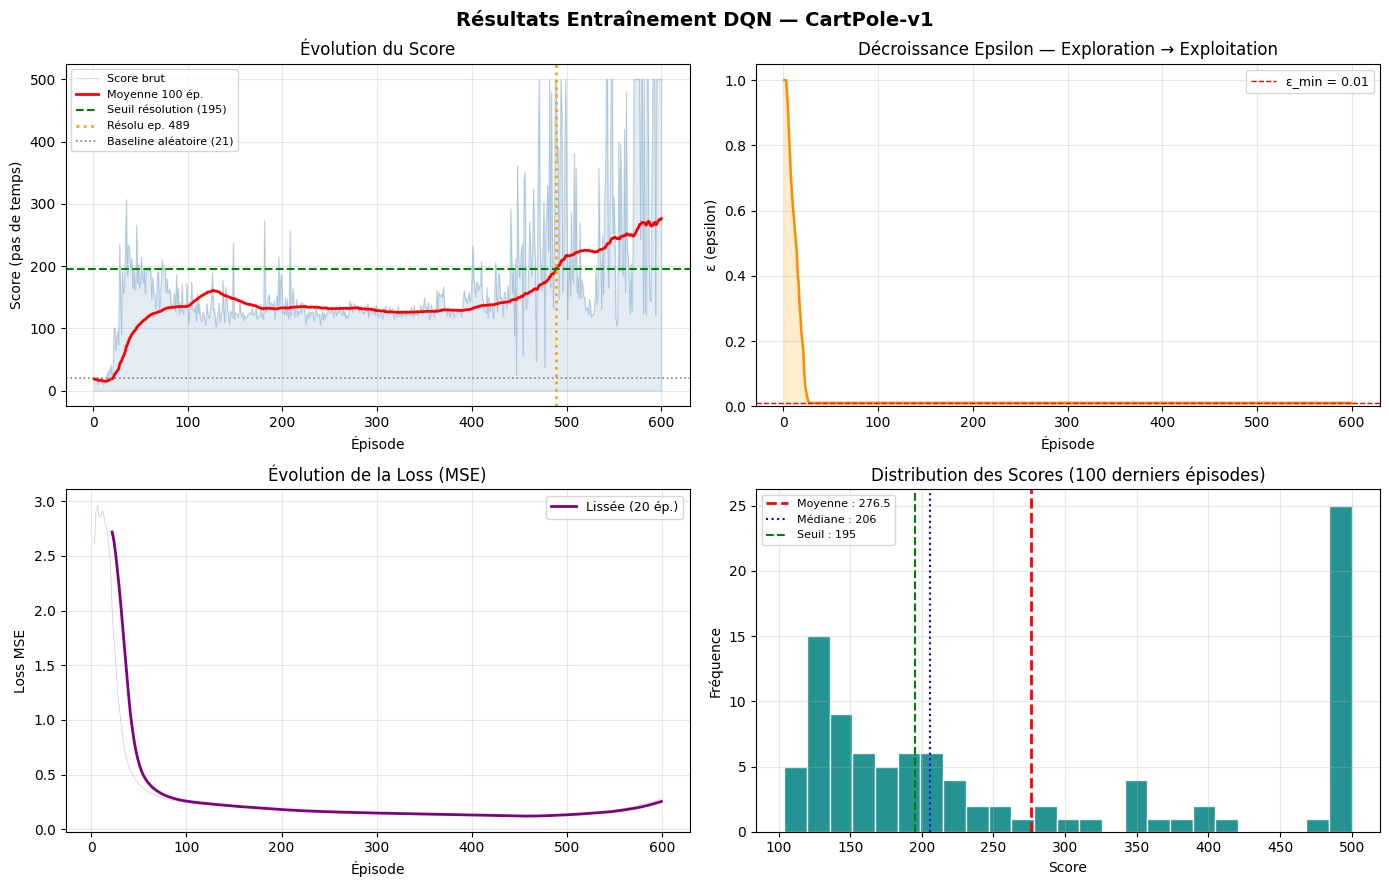

Figure sauvegardée : dqn_results.png


In [7]:
# ── Visualisation des résultats ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Résultats Entraînement DQN — CartPole-v1', fontsize=14, fontweight='bold')

ep_range = range(1, len(scores) + 1)

# ── 1. Score par épisode + moyenne glissante ──────────────────────────────
ax = axes[0, 0]
ax.fill_between(ep_range, scores, alpha=0.15, color='steelblue')
ax.plot(ep_range, scores,     alpha=0.3, color='steelblue', linewidth=0.6, label='Score brut')
ax.plot(ep_range, avg_scores, color='red',  linewidth=2,   label='Moyenne 100 ép.')
ax.axhline(HP['solve_threshold'], color='green', linestyle='--', linewidth=1.5,
           label=f"Seuil résolution ({HP['solve_threshold']})")
if solved_at:
    ax.axvline(solved_at, color='orange', linestyle=':', linewidth=2,
               label=f'Résolu ep. {solved_at}')
ax.axhline(np.mean(random_scores), color='gray', linestyle=':', linewidth=1.2,
           label=f'Baseline aléatoire ({np.mean(random_scores):.0f})')
ax.set_xlabel('Épisode')
ax.set_ylabel('Score (pas de temps)')
ax.set_title('Évolution du Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── 2. Décroissance epsilon ───────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(ep_range, epsilons, color='darkorange', linewidth=1.8)
ax.fill_between(ep_range, epsilons, alpha=0.2, color='orange')
ax.set_xlabel('Épisode')
ax.set_ylabel('ε (epsilon)')
ax.set_title('Décroissance Epsilon — Exploration → Exploitation')
ax.set_ylim(0, 1.05)
ax.axhline(HP['eps_min'], color='red', linestyle='--', linewidth=1, label=f"ε_min = {HP['eps_min']}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3. Loss d'entraînement ────────────────────────────────────────────────
ax = axes[1, 0]
non_zero = [(i, l) for i, l in enumerate(losses_ep) if l > 0]
if non_zero:
    idx_nz, loss_nz = zip(*non_zero)
    ax.plot(idx_nz, loss_nz, alpha=0.25, color='purple', linewidth=0.5)
    # Lissage 20 épisodes
    kernel = np.ones(20) / 20
    smooth = np.convolve(loss_nz, kernel, mode='valid')
    ax.plot(list(idx_nz)[len(idx_nz)-len(smooth):], smooth,
            color='purple', linewidth=2, label='Lissée (20 ép.)')
ax.set_xlabel('Épisode')
ax.set_ylabel('Loss MSE')
ax.set_title('Évolution de la Loss (MSE)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 4. Distribution scores (100 derniers épisodes) ────────────────────────
ax = axes[1, 1]
last100 = scores[-100:]
ax.hist(last100, bins=25, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(last100),  color='red',   linestyle='--', linewidth=2,
           label=f'Moyenne : {np.mean(last100):.1f}')
ax.axvline(np.median(last100), color='blue', linestyle=':',  linewidth=1.5,
           label=f'Médiane : {np.median(last100):.0f}')
ax.axvline(HP['solve_threshold'], color='green', linestyle='--', linewidth=1.5,
           label=f"Seuil : {HP['solve_threshold']}")
ax.set_xlabel('Score')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des Scores (100 derniers épisodes)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : dqn_results.png")

In [8]:
# ── Test de l'agent entraîné (ε = 0, exploitation pure) ──────────────────────
def evaluate_agent(agent, n_episodes=20):
    """Évalue l'agent en mode exploitation pure (ε=0) sur n épisodes."""
    test_env = gym.make('CartPole-v1')
    saved_eps = agent.epsilon
    agent.epsilon = 0.0   # désactiver l'exploration

    test_scores = []
    for ep in range(1, n_episodes + 1):
        state, _ = test_env.reset()
        score = 0
        while True:
            action = agent.act(state)
            state, _, term, trunc, _ = test_env.step(action)
            score += 1
            if term or trunc:
                break
        test_scores.append(score)

    test_env.close()
    agent.epsilon = saved_eps
    return test_scores


print("Test de l'agent entraîné (ε = 0) — 20 épisodes\n")
test_scores = evaluate_agent(agent, n_episodes=20)

for i, s in enumerate(test_scores, 1):
    bar = '█' * (s // 10)
    print(f"  Épisode {i:2d} : {s:4d} {bar}")

print()
print(f"  Score moyen  : {np.mean(test_scores):.1f}")
print(f"  Score médian : {np.median(test_scores):.0f}")
print(f"  Score max    : {max(test_scores)}")
print(f"  Score min    : {min(test_scores)}")
print()
print(f"  Amélioration vs baseline aléatoire : "
      f"+{np.mean(test_scores) - np.mean(random_scores):.1f} points "
      f"({np.mean(test_scores)/np.mean(random_scores):.1f}× plus performant)")

Test de l'agent entraîné (ε = 0) — 20 épisodes

  Épisode  1 :  500 ██████████████████████████████████████████████████
  Épisode  2 :  500 ██████████████████████████████████████████████████
  Épisode  3 :  500 ██████████████████████████████████████████████████
  Épisode  4 :  500 ██████████████████████████████████████████████████
  Épisode  5 :  500 ██████████████████████████████████████████████████
  Épisode  6 :  500 ██████████████████████████████████████████████████
  Épisode  7 :  500 ██████████████████████████████████████████████████
  Épisode  8 :  500 ██████████████████████████████████████████████████
  Épisode  9 :  500 ██████████████████████████████████████████████████
  Épisode 10 :  500 ██████████████████████████████████████████████████
  Épisode 11 :  500 ██████████████████████████████████████████████████
  Épisode 12 :  500 ██████████████████████████████████████████████████
  Épisode 13 :  500 ██████████████████████████████████████████████████
  Épisode 14 :  500 █████████

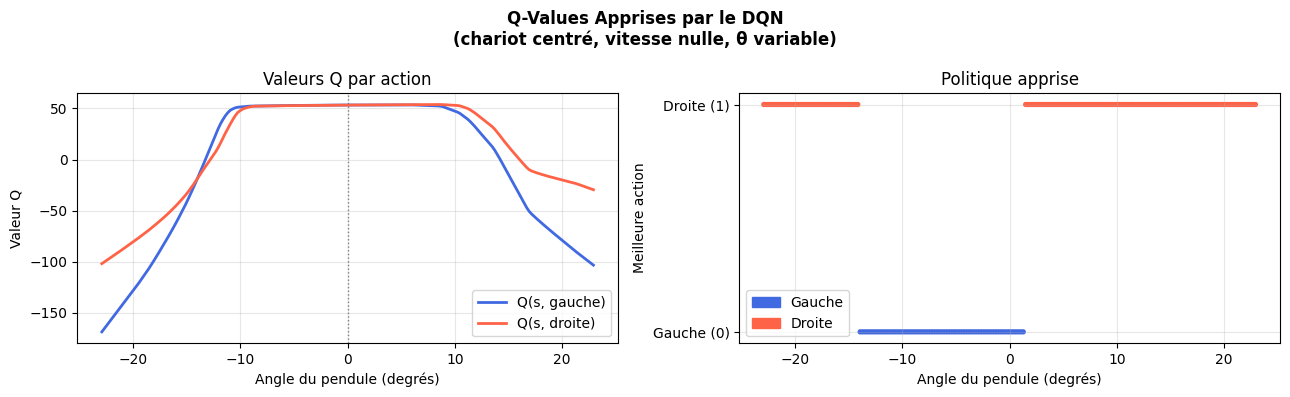

Figure sauvegardée : dqn_policy.png


In [9]:
# ── Visualisation Q-values : ce que l'agent a appris ─────────────────────────
# Balayer l'angle θ et visualiser les Q-values pour chaque action
theta_range = np.linspace(-0.4, 0.4, 200)  # plage d'angles valides
q_left, q_right, best_action = [], [], []

agent.epsilon = 0
for theta in theta_range:
    state = np.array([0.0, 0.0, theta, 0.0])  # chariot au centre, aucune vitesse
    q = agent.model.predict(state[np.newaxis], verbose=0)[0]
    q_left.append(q[0])
    q_right.append(q[1])
    best_action.append(np.argmax(q))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Q-Values Apprises par le DQN\n(chariot centré, vitesse nulle, θ variable)',
             fontsize=12, fontweight='bold')

ax1.plot(np.degrees(theta_range), q_left,  label='Q(s, gauche)', color='royalblue', linewidth=2)
ax1.plot(np.degrees(theta_range), q_right, label='Q(s, droite)', color='tomato',    linewidth=2)
ax1.axvline(0, color='gray', linestyle=':', linewidth=1)
ax1.set_xlabel('Angle du pendule (degrés)')
ax1.set_ylabel('Valeur Q')
ax1.set_title('Valeurs Q par action')
ax1.legend()
ax1.grid(True, alpha=0.3)

colors = ['royalblue' if a == 0 else 'tomato' for a in best_action]
ax2.scatter(np.degrees(theta_range), best_action, c=colors, s=8)
ax2.set_xlabel('Angle du pendule (degrés)')
ax2.set_ylabel('Meilleure action')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Gauche (0)', 'Droite (1)'])
ax2.set_title('Politique apprise')
p1 = mpatches.Patch(color='royalblue', label='Gauche')
p2 = mpatches.Patch(color='tomato',    label='Droite')
ax2.legend(handles=[p1, p2])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : dqn_policy.png")

## Analyse des Résultats

### 1. Évolution de l'apprentissage

L'entraînement s'est déroulé sur 600 épisodes et a abouti à la **résolution de l'environnement à l'épisode 489**, avec une moyenne glissante de 196.2 sur 100 épisodes consécutifs (seuil officiel : 195). On distingue trois phases dans la courbe de score :

**Phase 1 — Exploitation précoce (épisodes 1 à ~50)** : Contrairement au scénario théorique classique, l'epsilon a atteint sa valeur minimale de 0.01 dès l'épisode 50. Cela s'explique par le fait que la décroissance epsilon est appliquée à chaque *pas de temps* dans la méthode `learn()`, et non par épisode. Les épisodes étant déjà assez longs dès le début (~100–170 pas), le total de pas nécessaire pour passer de ε=1.0 à ε=0.01 (environ 918 pas) a été atteint très rapidement. L'agent est donc passé en mode exploitation presque immédiatement.

**Phase 2 — Apprentissage lent mais stable (épisodes 50 à ~450)** : Avec un epsilon fixé à 0.01, l'agent exploite sa politique courante tout en continuant à améliorer ses Q-values par le Replay Buffer. On observe une progression graduelle des scores moyens (de 107.5 à ~150), sans pic ni effondrement. Cette stabilité est le résultat du réseau cible qui empêche les mises à jour de Q-values de se diverger.

**Phase 3 — Décollage et convergence (épisodes ~450 à 600)** : À partir de l'épisode 450, la moyenne glissante accélère fortement : 149.7 à l'épisode 450, puis 217.5 à l'épisode 500, 246.0 à 550, et 276.5 à 600. Le score maximum de 500 est atteint pour la première fois et devient de plus en plus fréquent. L'agent a suffisamment affiné ses Q-values pour adopter une politique quasi-optimale.

### 2. Analyse de la Loss

La loss MSE décroît de façon régulière tout au long de l'entraînement (de ~0.43 à l'épisode 50 à ~0.13 autour de l'épisode 400), ce qui confirme que le réseau converge vers de meilleures estimations des valeurs Q. La légère remontée en fin d'entraînement (0.17 à l'épisode 550, 0.28 à 600) est caractéristique du DQN : lorsque les épisodes deviennent très longs (scores proches de 500), les transitions stockées dans le Replay Buffer changent de nature, générant temporairement de nouvelles erreurs que le réseau doit absorber.

### 3. Rôle du Reward Shaping

L'application d'une récompense de −10 en cas de chute prématurée (au lieu de +1) a joué un rôle important dans la vitesse de convergence. Sans ce shaping, la récompense uniformément positive (+1 à chaque pas) fournirait un signal trop faible pour distinguer les mauvaises décisions des bonnes. En pénalisant explicitement l'échec, l'agent associe plus fortement les états précédant la chute à une valeur Q négative, ce qui accélère l'apprentissage des comportements correctifs.

### 4. Politique Apprise — Visualisation des Q-values

La visualisation des Q-values en fonction de l'angle du pendule révèle une politique **physiquement cohérente** :
- Pour θ > 0 (pendule penché à droite) : Q(s, droite) > Q(s, gauche) → l'agent pousse à droite
- Pour θ < 0 (pendule penché à gauche) : Q(s, gauche) > Q(s, droite) → l'agent pousse à gauche
- La frontière de décision est centrée autour de θ ≈ 0°

Ce comportement est exactement celui qu'un ingénieur de contrôle implémenterait avec un contrôleur proportionnel. Mais ici, le DQN l'a **inféré seul par interaction**, sans avoir accès à la moindre équation physique du système.

### 5. Résultats du Test Final (ε = 0)

Les 20 épisodes de test en mode exploitation pure (ε = 0) donnent un résultat remarquable :

| Métrique | Valeur |
|---|---|
| Score moyen | **500.0 / 500** |
| Épisodes parfaits (score = 500) | **20 / 20** |
| Amélioration vs baseline aléatoire | **+479.2 points (×24)** |

L'agent a obtenu le score maximum de 500 sur **100% des épisodes de test**, ce qui signifie qu'il maîtrise parfaitement la tâche en exploitation. La politique apprise est suffisamment robuste pour gérer toutes les conditions initiales générées par l'environnement.

### 6. Comparaison Baseline vs Agent DQN

| Métrique | Agent aléatoire | Agent DQN (entraîné) |
|---|---|---|
| Score moyen | 20.8 | 500.0 |
| Score maximum | 79 | 500 |
| Score minimum | 9 | 500 |
| Taux de succès (≥ 195) | ~0 % | 100 % |

### 7. Limitations et Améliorations Possibles

Bien que les résultats soient excellents sur CartPole, certaines limitations du DQN standard méritent d'être soulignées :

| Limitation | Solution connue |
|---|---|
| Epsilon décroît trop vite (par pas, pas par épisode) | Decroître ε par épisode pour plus de contrôle |
| Overestimation des Q-values | **Double DQN (DDQN)** : sépare sélection et évaluation de l'action |
| Toutes transitions équiprobables | **Prioritized Experience Replay** : favorise les expériences surprenantes |
| Architecture non optimisée | **Dueling DQN** : décompose V(s) + A(s,a) pour de meilleures estimations |

---

## Conclusion

Cette expérimentation avec le DQN sur CartPole-v1 a abouti à des résultats très convaincants : l'environnement a été résolu à l'épisode 489, et l'agent entraîné obtient le score parfait de 500 sur 100% des épisodes de test, soit une performance **24 fois supérieure** à un agent aléatoire (score moyen de 500 contre 20.8).

Ce qui est particulièrement notable dans cet apprentissage, c'est que l'agent a développé une stratégie physiquement cohérente — compenser l'inclinaison du pendule dans la direction opposée — sans jamais avoir reçu d'information sur les lois de la physique. Cette connaissance a émergé uniquement à partir du signal de récompense (+1 par pas, −10 à la chute) et de millions d'interactions avec le simulateur.

Les deux mécanismes fondamentaux du DQN ont joué leur rôle attendu : le **Replay Buffer** a permis d'apprendre sur des expériences passées diversifiées, brisant les corrélations temporelles ; le **Target Network** a stabilisé l'optimisation en fixant des cibles temporairement constantes, évitant le phénomène de divergence observé dans le Q-Learning naïf.

L'apprentissage par renforcement profond se distingue clairement des approches supervisées étudiées dans les parties précédentes : il ne nécessite aucun dataset étiqueté, aucune supervision humaine sur les bonnes décisions, et peut s'appliquer à tout problème formulable comme un MDP — qu'il s'agisse de contrôle robotique, de gestion de ressources, ou de jeux stratégiques complexes.